In [20]:
# Install YOLOv8
!pip install ultralytics --quiet

import os
import glob
import re
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# --- CONFIGURATION ---
# Path to the specific ADL folder in UR Fall Detection Dataset
DATASET_PATH = "/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb"

# Load the Pose Model (YOLOv8n-pose is lightweight for real-time targets)
# Change this:
# model = YOLO("yolov8n-pose.pt")

# To this:
model = YOLO("yolov8n-pose.pt").to('cpu') 
print("✅ YOLOv8 Pose Model Loaded on CPU to avoid CUDA mismatch.")

# --- UTILITY: NUMERIC SORTING ---
def extract_num(path):
    """Extracts the frame number from the filename to ensure correct temporal order."""
    nums = re.findall(r'\d+', os.path.basename(path))
    return int(nums[-1]) if nums else -1

# Collect and sort paths
image_paths = sorted(glob.glob(os.path.join(DATASET_PATH, "*.png")), key=extract_num)
print(f"✅ Loaded {len(image_paths)} frames from {DATASET_PATH}")

✅ YOLOv8 Pose Model Loaded on CPU to avoid CUDA mismatch.
✅ Loaded 180 frames from /kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb


In [21]:
def get_person_mask(frame, results):
    """Phase 3: Creates a binary mask over the detected person[cite: 77]."""
    mask = np.zeros(frame.shape[:2], dtype=np.uint8)
    if results.boxes:
        for box in results.boxes.xyxy:
            x1, y1, x2, y2 = map(int, box)
            # Add margin to ensure complete silhouette removal [cite: 49]
            margin = 15
            cv2.rectangle(mask, 
                          (max(0, x1 - margin), max(0, y1 - margin)), 
                          (min(frame.shape[1], x2 + margin), min(frame.shape[0], y2 + margin)), 
                          255, -1)
    return mask

def generate_ghost_stream(frame, results):
    """Phase 3: Erases the human pixels using Inpainting[cite: 78, 86]."""
    # 1. Generate the mask from pose detections
    mask = get_person_mask(frame, results)
    
    # 2. Inpaint the background (Telea algorithm as per Bertalmio et al.) [cite: 135]
    ghost_bg = cv2.inpaint(frame, mask, 3, cv2.INPAINT_TELEA)
    
    # 3. Render the skeleton proxy onto the clean background [cite: 22, 83]
    # This ensures identity is removed while behavior is preserved.
    ghost_frame = results.plot(img=ghost_bg) 
    
    return ghost_frame

🚀 Starting Ghost-Cam Pipeline...

0: 480x640 1 person, 122.5ms
Speed: 4.0ms preprocess, 122.5ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 107.1ms
Speed: 2.0ms preprocess, 107.1ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 106.0ms
Speed: 2.8ms preprocess, 106.0ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 106.2ms
Speed: 1.9ms preprocess, 106.2ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 108.6ms
Speed: 2.0ms preprocess, 108.6ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 105.4ms
Speed: 2.0ms preprocess, 105.4ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 105.2ms
Speed: 2.0ms preprocess, 105.2ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 103.4ms
Speed: 2.0ms preprocess, 103.4ms inferenc

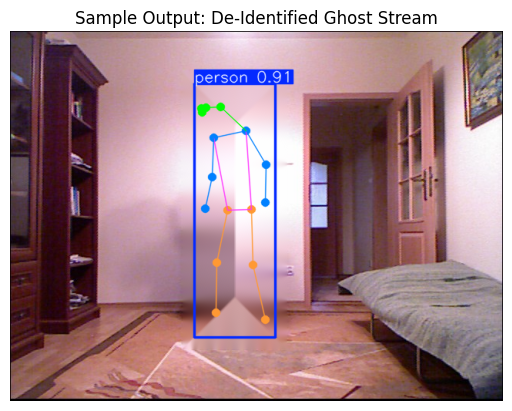

In [22]:
# --- MAIN PIPELINE ---
ghost_frames = []
all_keypoints = []
start_time = time.time()

print("🚀 Starting Ghost-Cam Pipeline...")

for img_path in image_paths:
    frame = cv2.imread(img_path)
    if frame is None: continue
    
    # Run Pose Estimation (Phase 2) [cite: 73]
    results = model(frame)[0]
    
    # Apply De-Identification (Phase 3) [cite: 49, 116]
    ghost_frame = generate_ghost_stream(frame, results)
    ghost_frames.append(ghost_frame)
    
    # Save keypoints for Phase 4 (Behavioral Detection) [cite: 87, 118]
    if results.keypoints:
        all_keypoints.append(results.keypoints.xy[0].tolist())
    else:
        all_keypoints.append(None)

end_time = time.time()
fps = len(image_paths) / (end_time - start_time)
print(f"✨ Processing Complete! Average FPS: {fps:.2f}") # Target is >= 15 [cite: 89, 121]

# --- PREVIEW RESULT ---
plt.imshow(cv2.cvtColor(ghost_frames[len(ghost_frames)//2], cv2.COLOR_BGR2RGB))
plt.title("Sample Output: De-Identified Ghost Stream")
plt.axis("off")
plt.show()

In [23]:
import json

# 1. VIDEO OUTPUT SETUP [cite: 86]
# Use the dimensions from your processed ghost_frames
h, w, _ = ghost_frames[0].shape
video_filename = "Ghost_Stream_Output.mp4"

# Define codec and VideoWriter (15 FPS target as per synopsis) [cite: 89, 121]
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(video_filename, fourcc, 15.0, (w, h))

# 2. METADATA SETUP [cite: 87, 118, 126]
# This replaces raw video for long-term storage
metadata = {
    "project": "Ghost-Cam",
    "timestamp": time.ctime(),
    "frames": []
}

print(f"🎬 Compiling {len(ghost_frames)} frames and generating JSON metadata...")

for i, frame in enumerate(ghost_frames):
    # Write the de-identified frame to the video file
    out.write(frame)
    
    # Extract coordinates to the JSON structure (Behavioral Telemetry) [cite: 33, 39]
    frame_entry = {
        "frame_index": i,
        "keypoints": all_keypoints[i] if all_keypoints[i] is not None else []
    }
    metadata["frames"].append(frame_entry)

# 3. SAVE AND RELEASE [cite: 53]
out.release()

with open("behavioral_metadata.json", "w") as f:
    json.dump(metadata, f)

print(f"✅ 'Ghost Stream' video saved: {video_filename}")
print(f"✅ Behavioral JSON metadata saved: behavioral_metadata.json")

🎬 Compiling 180 frames and generating JSON metadata...
✅ 'Ghost Stream' video saved: Ghost_Stream_Output.mp4
✅ Behavioral JSON metadata saved: behavioral_metadata.json


✅ YOLOv8 Pose Model Loaded on CPU to avoid CUDA mismatch.
✅ Loaded 180 frames from /kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb
🚀 Starting Ghost-Cam Pipeline...

0: 480x640 1 person, 244.6ms
Speed: 8.4ms preprocess, 244.6ms inference, 15.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 116.4ms
Speed: 1.8ms preprocess, 116.4ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 116.3ms
Speed: 2.9ms preprocess, 116.3ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 116.0ms
Speed: 1.9ms preprocess, 116.0ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 111.2ms
Speed: 1.7ms preprocess, 111.2ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 120.5ms
Speed: 1.7ms preprocess, 120.5ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 

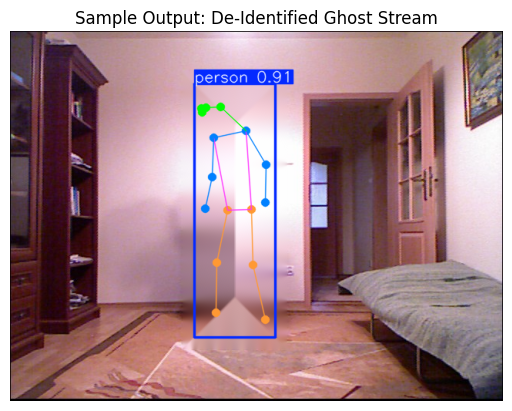

🎬 Compiling 180 frames and generating JSON metadata...
✅ 'Ghost Stream' video saved: Ghost_Stream_Output.mp4
✅ Behavioral JSON metadata saved: behavioral_metadata.json


In [14]:
# Install YOLOv8
!pip install ultralytics --quiet

import os
import glob
import re
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# --- CONFIGURATION ---
DATASET_PATH = "/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb"

# Load YOLO Pose Model on CPU
model = YOLO("yolov8n-pose.pt").to('cpu')
print("✅ YOLOv8 Pose Model Loaded on CPU to avoid CUDA mismatch.")

# --- UTILITY: NUMERIC SORTING ---
def extract_num(path):
    """Extracts the frame number from the filename to ensure correct temporal order."""
    nums = re.findall(r'\d+', os.path.basename(path))
    return int(nums[-1]) if nums else -1

# Collect and sort dataset frames
image_paths = sorted(glob.glob(os.path.join(DATASET_PATH, "*.png")), key=extract_num)
print(f"✅ Loaded {len(image_paths)} frames from {DATASET_PATH}")

# --- PHASE 3: PERSON MASK (IMPROVED) ---
def get_person_mask(frame, results):
    """Creates a binary mask using bounding box + convex hull for high-quality de-identification."""
    mask = np.zeros(frame.shape[:2], dtype=np.uint8)

    # Bounding box region
    if results.boxes:
        for box in results.boxes.xyxy:
            x1, y1, x2, y2 = map(int, box)
            margin = 15
            cv2.rectangle(mask,
                          (max(0, x1 - margin), max(0, y1 - margin)),
                          (min(frame.shape[1], x2 + margin), min(frame.shape[0], y2 + margin)),
                          255, -1)

    # Convex hull of keypoints (better privacy and accuracy)
    if results.keypoints:
        pts = np.array(results.keypoints.xy[0], dtype=np.int32)
        if len(pts) > 2:
            hull = cv2.convexHull(pts)
            cv2.fillConvexPoly(mask, hull, 255)

    return mask

# --- PHASE 3: DE-IDENTIFICATION (INPAINTING + SKELETON OVERLAY) ---
def generate_ghost_stream(frame, results):
    """Removes human pixels, reconstructs background, and overlays the skeleton proxy."""
    mask = get_person_mask(frame, results)
    ghost_bg = cv2.inpaint(frame, mask, 3, cv2.INPAINT_TELEA)
    ghost_frame = results.plot(img=ghost_bg)
    return ghost_frame

# --- MAIN PIPELINE (TILL DE-IDENTIFICATION ONLY) ---
ghost_frames = []
all_keypoints = []
start_time = time.time()

print("🚀 Starting Ghost-Cam Pipeline...")

for img_path in image_paths:
    frame = cv2.imread(img_path)
    if frame is None:
        continue

    # Pose Estimation
    results = model(frame)[0]

    # De-Identification: Background inpainting + Skeleton overlay
    ghost_frame = generate_ghost_stream(frame, results)
    ghost_frames.append(ghost_frame)

    # Save keypoints for metadata
    if results.keypoints:
        all_keypoints.append(results.keypoints.xy[0].tolist())
    else:
        all_keypoints.append(None)

end_time = time.time()
fps = len(image_paths) / (end_time - start_time)

print(f"✨ Processing Complete! Average FPS: {fps:.2f}")

# --- PREVIEW RESULT ---
plt.imshow(cv2.cvtColor(ghost_frames[len(ghost_frames)//2], cv2.COLOR_BGR2RGB))
plt.title("Sample Output: De-Identified Ghost Stream")
plt.axis("off")
plt.show()

# --- SAVE VIDEO + JSON METADATA ---
import json

# Setup video writer
h, w, _ = ghost_frames[0].shape
video_filename = "Ghost_Stream_Output.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(video_filename, fourcc, 15.0, (w, h))

# Prepare metadata
metadata = {
    "project": "Ghost-Cam",
    "timestamp": time.ctime(),
    "frames": []
}

print(f"🎬 Compiling {len(ghost_frames)} frames and generating JSON metadata...")

for i, frame in enumerate(ghost_frames):
    out.write(frame)

    frame_entry = {
        "frame_index": i,
        "keypoints": all_keypoints[i] if all_keypoints[i] is not None else []
    }
    metadata["frames"].append(frame_entry)

# Save everything
out.release()
with open("behavioral_metadata.json", "w") as f:
    json.dump(metadata, f)

print(f"✅ 'Ghost Stream' video saved: {video_filename}")
print(f"✅ Behavioral JSON metadata saved: behavioral_metadata.json")

In [19]:
# Install YOLOv8
!pip install ultralytics --quiet

import os
import glob
import re
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import json
import math

# --- CONFIGURATION ---
DATASET_PATH = "/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb"

# Load YOLOv8 Pose model (CPU)
model = YOLO("yolov8n-pose.pt").to('cpu')
print("✅ YOLOv8 Pose Model Loaded on CPU.")

# --- SORT FRAMES ---
def extract_num(path):
    nums = re.findall(r'\d+', os.path.basename(path))
    return int(nums[-1]) if nums else -1

image_paths = sorted(glob.glob(os.path.join(DATASET_PATH, "*.png")), key=extract_num)
print(f"✅ Loaded {len(image_paths)} frames.")

# =========================
# PHASE 3: DE-IDENTIFICATION
# =========================

def get_person_mask(frame, results):
    mask = np.zeros(frame.shape[:2], dtype=np.uint8)

    if results.boxes:
        for box in results.boxes.xyxy:
            x1, y1, x2, y2 = map(int, box)
            margin = 15
            cv2.rectangle(mask,
                          (max(0, x1-margin), max(0, y1-margin)),
                          (min(frame.shape[1], x2+margin), min(frame.shape[0], y2+margin)),
                          255, -1)

    if results.keypoints:
        pts = np.array(results.keypoints.xy[0], dtype=np.int32)
        if len(pts) > 2:
            hull = cv2.convexHull(pts)
            cv2.fillConvexPoly(mask, hull, 255)

    return mask


def generate_ghost_stream(frame, results):
    mask = get_person_mask(frame, results)
    clean_bg = cv2.inpaint(frame, mask, 3, cv2.INPAINT_TELEA)
    ghost_frame = results.plot(img=clean_bg)
    return ghost_frame

# =========================
# PHASE 4: ACTIVITY ANALYSIS
# =========================

def distance(p1, p2):
    return math.dist(p1, p2)

def avg_y(points):
    return sum([p[1] for p in points]) / len(points)

def classify_activity(kp, prev_kp=None):
    if kp is None:
        return "no_person"

    # Key joints
    head = kp[0]
    L_sh, R_sh = kp[5], kp[6]
    L_hip, R_hip = kp[11], kp[12]
    L_kn, R_kn = kp[13], kp[14]
    L_an, R_an = kp[15], kp[16]

    shoulder_y = avg_y([L_sh, R_sh])
    hip_y = avg_y([L_hip, R_hip])
    knee_y = avg_y([L_kn, R_kn])
    ankle_y = avg_y([L_an, R_an])

    body_height = ankle_y - head[1]

    # --- Lying ---
    if abs(L_sh[1] - R_sh[1]) < 20 and abs(L_hip[1] - R_hip[1]) < 20:
        if body_height < 80:
            return "lying"

    # --- Sitting ---
    if abs(hip_y - knee_y) < 40:
        return "sitting"

    # --- Bending ---
    if head[1] - shoulder_y > 40:
        return "bending"

    # --- Walking (IMPROVED) ---
    L_leg = distance(L_kn, L_an)
    R_leg = distance(R_kn, R_an)
    leg_diff = abs(L_leg - R_leg)

    walking_by_leg = leg_diff > 12

    walking_by_motion = False
    if prev_kp is not None:
        prev_La = prev_kp[15]
        prev_Ra = prev_kp[16]

        move_L = abs(L_an[0] - prev_La[0])
        move_R = abs(R_an[0] - prev_Ra[0])

        if move_L > 3 or move_R > 3:
            walking_by_motion = True

    if walking_by_leg or walking_by_motion:
        return "walking"

    return "standing"


def detect_fall(prev_kp, curr_kp, threshold=40):
    if prev_kp is None or curr_kp is None:
        return False

    prev_head = prev_kp[0][1]
    curr_head = curr_kp[0][1]

    return (curr_head - prev_head) > threshold

# =========================
# MAIN PIPELINE
# =========================

ghost_frames = []
metadata = {"project": "Ghost-Cam", "timestamp": time.ctime(), "frames": []}

prev_kp = None
start_time = time.time()

print("🚀 Running Full Pipeline...")

for i, img_path in enumerate(image_paths):

    frame = cv2.imread(img_path)
    if frame is None:
        continue

    results = model(frame)[0]

    ghost_frame = generate_ghost_stream(frame, results)

    # Extract keypoints
    if results.keypoints:
        curr_kp = results.keypoints.xy[0].tolist()
    else:
        curr_kp = None

    # Activity + Fall
    activity = classify_activity(curr_kp, prev_kp)
    fall_flag = detect_fall(prev_kp, curr_kp)

    # Overlay text
    cv2.putText(ghost_frame, f"Activity: {activity}",
                (20,50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,0), 2)

    if fall_flag:
        cv2.putText(ghost_frame, "⚠ FALL DETECTED!",
                    (20,120), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 3)

    ghost_frames.append(ghost_frame)

    metadata["frames"].append({
        "frame_index": i,
        "activity": activity,
        "fall_detected": fall_flag,
        "keypoints": curr_kp if curr_kp else [],
        "timestamp": time.time()
    })

    prev_kp = curr_kp

end_time = time.time()
fps = len(image_paths) / (end_time - start_time)
print(f"✨ Done! FPS: {fps:.2f}")

# =========================
# SAVE OUTPUTS
# =========================

h, w, _ = ghost_frames[0].shape
video = cv2.VideoWriter("Ghost_Stream_Activity_FIXED.mp4",
                        cv2.VideoWriter_fourcc(*"mp4v"),
                        15,
                        (w, h))

for f in ghost_frames:
    video.write(f)

video.release()

with open("activity_metadata_FIXED.json", "w") as f:
    json.dump(metadata, f)

print("🎬 Video saved: Ghost_Stream_Activity_FIXED.mp4")
print("📄 Metadata saved: activity_metadata_FIXED.json")

✅ YOLOv8 Pose Model Loaded on CPU.
✅ Loaded 180 frames.
🚀 Running Full Pipeline...

0: 480x640 1 person, 125.2ms
Speed: 4.1ms preprocess, 125.2ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 109.8ms
Speed: 1.9ms preprocess, 109.8ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 109.6ms
Speed: 2.0ms preprocess, 109.6ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 114.7ms
Speed: 1.9ms preprocess, 114.7ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 114.5ms
Speed: 1.7ms preprocess, 114.5ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 111.1ms
Speed: 2.0ms preprocess, 111.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 109.1ms
Speed: 1.8ms preprocess, 109.1ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person,

In [20]:
# Install YOLOv8
!pip install ultralytics --quiet

import os
import glob
import re
import cv2
import time
import numpy as np
import json
import math
from ultralytics import YOLO

# =============================
# DATASET PATH (YOUR NEW FOLDER)
# =============================
DATASET_PATH = "/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/fall-17-cam0-rgb"

# Load YOLO Pose model
model = YOLO("yolov8n-pose.pt").to("cpu")
print("✅ Model Loaded")

# =============================
# SORT FRAMES
# =============================
def extract_num(path):
    nums = re.findall(r'\d+', os.path.basename(path))
    return int(nums[-1]) if nums else -1

image_paths = sorted(glob.glob(os.path.join(DATASET_PATH, "*.png")), key=extract_num)
print(f"📸 Frames loaded: {len(image_paths)}")

# =============================
# HELPER FUNCTIONS
# =============================
def distance(p1, p2):
    return math.dist(p1, p2)

def avg_y(pts):
    return sum([p[1] for p in pts]) / len(pts)

# ---- DE-IDENTIFICATION ----
def get_person_mask(frame, results):
    mask = np.zeros(frame.shape[:2], dtype=np.uint8)

    if results.boxes:
        for box in results.boxes.xyxy:
            x1, y1, x2, y2 = map(int, box)
            margin = 15
            cv2.rectangle(mask,
                          (max(0, x1-margin), max(0, y1-margin)),
                          (min(frame.shape[1], x2+margin), min(frame.shape[0], y2+margin)),
                          255, -1)

    if results.keypoints:
        pts = np.array(results.keypoints.xy[0], dtype=np.int32)
        if len(pts) > 2:
            hull = cv2.convexHull(pts)
            cv2.fillConvexPoly(mask, hull, 255)

    return mask

def generate_ghost_stream(frame, results):
    mask = get_person_mask(frame, results)
    clean = cv2.inpaint(frame, mask, 3, cv2.INPAINT_TELEA)
    ghost = results.plot(img=clean)
    return ghost

# ---- ACTIVITY ----
def classify_activity(kp, prev_kp=None):
    if kp is None:
        return "no_person"

    head = kp[0]
    L_sh, R_sh = kp[5], kp[6]
    L_hip, R_hip = kp[11], kp[12]
    L_kn, R_kn = kp[13], kp[14]
    L_an, R_an = kp[15], kp[16]

    shoulder_y = avg_y([L_sh, R_sh])
    hip_y = avg_y([L_hip, R_hip])
    knee_y = avg_y([L_kn, R_kn])
    ankle_y = avg_y([L_an, R_an])

    body_height = ankle_y - head[1]

    # Lying
    if abs(L_sh[1] - R_sh[1]) < 20 and abs(L_hip[1] - R_hip[1]) < 20:
        if body_height < 80:
            return "lying"

    # Sitting
    if abs(hip_y - knee_y) < 40:
        return "sitting"

    # Bending
    if head[1] - shoulder_y > 40:
        return "bending"

    # Walking
    L_leg = distance(L_kn, L_an)
    R_leg = distance(R_kn, R_an)

    walking_leg = abs(L_leg - R_leg) > 12

    walking_motion = False
    if prev_kp is not None:
        move_L = abs(L_an[0] - prev_kp[15][0])
        move_R = abs(R_an[0] - prev_kp[16][0])
        if move_L > 3 or move_R > 3:
            walking_motion = True

    if walking_leg or walking_motion:
        return "walking"

    return "standing"

def detect_fall(prev_kp, curr_kp, threshold=40):
    if prev_kp is None or curr_kp is None:
        return False
    return (curr_kp[0][1] - prev_kp[0][1]) > threshold

# =============================
# MAIN LOOP
# =============================
ghost_frames = []
metadata = {"frames": []}

prev_kp = None

print("🚀 Processing fall sequence...")

for i, img_path in enumerate(image_paths):

    frame = cv2.imread(img_path)
    if frame is None:
        continue

    results = model(frame)[0]
    ghost = generate_ghost_stream(frame, results)

    if results.keypoints:
        curr_kp = results.keypoints.xy[0].tolist()
    else:
        curr_kp = None

    activity = classify_activity(curr_kp, prev_kp)
    fall_flag = detect_fall(prev_kp, curr_kp)

    # Overlay text
    cv2.putText(ghost, f"Activity: {activity}", (20,50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,0), 2)

    if fall_flag:
        cv2.putText(ghost, "⚠ FALL DETECTED!", (20,120),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 3)

    ghost_frames.append(ghost)

    metadata["frames"].append({
        "frame": i,
        "activity": activity,
        "fall_detected": fall_flag
    })

    prev_kp = curr_kp

# =============================
# SAVE VIDEO
# =============================
h, w, _ = ghost_frames[0].shape
out = cv2.VideoWriter("fall_test_output.mp4",
                      cv2.VideoWriter_fourcc(*"mp4v"),
                      15,
                      (w, h))

for f in ghost_frames:
    out.write(f)

out.release()

with open("fall_test_metadata.json", "w") as f:
    json.dump(metadata, f)

print("🎬 Output saved: fall_test_output.mp4")
print("📄 Metadata saved: fall_test_metadata.json")

✅ Model Loaded
📸 Frames loaded: 95
🚀 Processing fall sequence...

0: 480x640 1 person, 120.4ms
Speed: 3.2ms preprocess, 120.4ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 111.1ms
Speed: 1.7ms preprocess, 111.1ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 105.6ms
Speed: 1.6ms preprocess, 105.6ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 102.2ms
Speed: 1.8ms preprocess, 102.2ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 102.8ms
Speed: 2.0ms preprocess, 102.8ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 108.5ms
Speed: 1.8ms preprocess, 108.5ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 105.1ms
Speed: 1.7ms preprocess, 105.1ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 105.4ms
Speed: 1.